<a href="https://colab.research.google.com/github/csabiu/Cosmology_Course/blob/main/practical/friedmann_einsteinpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The FLRW Metric and the Friedmann Equations
### A Computational Tutorial for Lecture 2 — Expanding Universe and Background Dynamics

---

## Introduction

In Lecture 1 we measured the Hubble constant from real data. Now we ask: *why* does the Universe expand, and *how* does the expansion evolve with time?

The answer lies in Einstein's General Relativity. In this notebook you will:
1. **Define the FLRW metric** symbolically and use EinsteinPy to compute the Christoffel symbols, Ricci tensor, and Einstein tensor
2. **Derive the Friedmann equations** directly from the Einstein tensor components
3. **Solve the Friedmann equations** numerically for single-component universes (matter, radiation, $\Lambda$) and compare with analytical solutions
4. **Integrate the full $\Lambda$CDM model** with observed cosmological parameters to compute the expansion history and age of the Universe

### Prerequisites
Basic Python (numpy, matplotlib, scipy). The symbolic computations use [EinsteinPy](https://einsteinpy.org/), built on SymPy.

### Key Equations

The FLRW line element:
$$ds^2 = -c^2\,dt^2 + a^2(t)\left[\frac{dr^2}{1-kr^2} + r^2(d\theta^2 + \sin^2\theta\,d\phi^2)\right]$$

The Friedmann equations (with $\Lambda$):
$$H^2 = \frac{8\pi G}{3}\rho - \frac{k}{a^2} + \frac{\Lambda}{3}$$
$$\frac{\ddot{a}}{a} = -\frac{4\pi G}{3}(\rho + 3p) + \frac{\Lambda}{3}$$

---

---
## Part 1 — The FLRW Metric with EinsteinPy

We begin by defining the FLRW metric symbolically and using EinsteinPy's symbolic module to compute the Christoffel symbols. This automates the tedious index algebra and lets us verify the results from the lecture notes.

In [2]:
pip install einsteinpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 2.9 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from scipy.optimize import brentq

import sympy
from sympy import (symbols, Function, sqrt, sin, cos, simplify,
                   Derivative, Rational, latex, pprint)
from einsteinpy.symbolic import (MetricTensor, ChristoffelSymbols,
                                  RicciTensor, RicciScalar, EinsteinTensor)

sympy.init_printing()

# Nice plot defaults (matching Lecture 1 notebook)
plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'axes.titlesize': 15,
    'legend.fontsize': 11,
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Defining the FLRW Metric

The Friedmann–Lemaître–Robertson–Walker (FLRW) metric is the most general metric for a **homogeneous and isotropic** spacetime. In spherical comoving coordinates $(t, r, \theta, \phi)$ and natural units ($c = 1$):

$$ds^2 = -dt^2 + a^2(t)\left[\frac{dr^2}{1-kr^2} + r^2\left(d\theta^2 + \sin^2\theta\,d\phi^2\right)\right]$$

The metric tensor $g_{\mu\nu}$ is diagonal with components:
- $g_{00} = -1$
- $g_{rr} = \frac{a^2(t)}{1 - kr^2}$
- $g_{\theta\theta} = a^2(t)\, r^2$
- $g_{\phi\phi} = a^2(t)\, r^2 \sin^2\theta$

where $a(t)$ is the **scale factor** and $k \in \{-1, 0, +1\}$ determines the spatial geometry (open, flat, or closed).

In [4]:
# Define coordinates and symbols
t, r, theta, phi = symbols('t r theta phi')
a = Function('a')(t)
k = symbols('k')

# FLRW metric components (natural units, c=1)
g00 = -1
g11 = a**2 / (1 - k * r**2)
g22 = a**2 * r**2
g33 = a**2 * r**2 * sin(theta)**2

# Build the 4x4 diagonal metric
metric_list = [[g00, 0, 0, 0],
               [0, g11, 0, 0],
               [0, 0, g22, 0],
               [0, 0, 0, g33]]

coords = (t, r, theta, phi)
flrw_metric = MetricTensor(metric_list, coords)

print("FLRW metric tensor g_μν:")
flrw_metric.tensor()

FLRW metric tensor g_μν:


⎡-1      0          0             0        ⎤
⎢                                          ⎥
⎢       2                                  ⎥
⎢      a (t)                               ⎥
⎢0   ──────────     0             0        ⎥
⎢         2                                ⎥
⎢    - k⋅r  + 1                            ⎥
⎢                                          ⎥
⎢                 2  2                     ⎥
⎢0       0       r ⋅a (t)         0        ⎥
⎢                                          ⎥
⎢                           2  2       2   ⎥
⎣0       0          0      r ⋅a (t)⋅sin (θ)⎦

### Computing the Christoffel Symbols

The Christoffel symbols (Levi-Civita connection) are defined as:

$$\Gamma^\mu_{\alpha\beta} = \frac{1}{2}g^{\mu\nu}\left(\partial_\alpha g_{\nu\beta} + \partial_\beta g_{\nu\alpha} - \partial_\nu g_{\alpha\beta}\right)$$

For the diagonal FLRW metric, most of the 40 independent components vanish. The non-zero ones encode how the expansion (through $H = \dot{a}/a$) affects the spacetime geometry.

In [5]:
# Compute Christoffel symbols from the FLRW metric
christoffels = ChristoffelSymbols.from_metric(flrw_metric)
ch_tensor = christoffels.tensor()

print("Christoffel symbols computed successfully.")
print(f"Tensor shape: {ch_tensor.shape}")

Christoffel symbols computed successfully.
Tensor shape: (4, 4, 4)


In [6]:
# Display all non-zero Christoffel symbols
coord_names = ['t', 'r', 'θ', 'φ']

print("Non-zero Christoffel symbols Γ^μ_{αβ}:")
print("=" * 65)
for mu in range(4):
    for alpha in range(4):
        for beta in range(alpha, 4):  # symmetric in lower indices
            val = simplify(ch_tensor[mu, alpha, beta])
            if val != 0:
                print(f"  Γ^{coord_names[mu]}_{{{coord_names[alpha]} {coord_names[beta]}}} = {val}")

Non-zero Christoffel symbols Γ^μ_{αβ}:
  Γ^t_{r r} = -a(t)*Derivative(a(t), t)/(k*r**2 - 1)
  Γ^t_{θ θ} = r**2*a(t)*Derivative(a(t), t)
  Γ^t_{φ φ} = r**2*a(t)*sin(theta)**2*Derivative(a(t), t)
  Γ^r_{t r} = Derivative(a(t), t)/a(t)
  Γ^r_{r r} = -k*r/(k*r**2 - 1)
  Γ^r_{θ θ} = k*r**3 - r
  Γ^r_{φ φ} = r*(k*r**2 - 1)*sin(theta)**2
  Γ^θ_{t θ} = Derivative(a(t), t)/a(t)
  Γ^θ_{r θ} = 1/r
  Γ^θ_{φ φ} = -sin(2*theta)/2
  Γ^φ_{t φ} = Derivative(a(t), t)/a(t)
  Γ^φ_{r φ} = 1/r
  Γ^φ_{θ φ} = 1/tan(theta)


### Verification against Lecture Notes

The results match Slide 12 of the lecture. The key physical interpretation:

- $\Gamma^0_{ij} \propto \dot{a} \cdot a \cdot (\text{spatial metric})$: the spatial metric is changing with time due to expansion
- $\Gamma^i_{0j} = H\,\delta^i_j = \dot{a}/a\,\delta^i_j$: basis vectors are stretched by expansion
- $\Gamma^0_{00} = \Gamma^0_{0i} = \Gamma^i_{00} = 0$: cosmic time flows uniformly; comoving observers are freely falling

The remaining $\Gamma^i_{jk}$ terms (involving $k/r$ or $\cot\theta$) are purely geometrical — they describe the curvature of spherical coordinates and spatial curvature, independent of expansion.

---
## Part 2 — Curvature and the Friedmann Equations from GR

With the Christoffel symbols in hand, we now compute the Ricci tensor, Ricci scalar, and Einstein tensor. The components of the Einstein tensor, combined with the energy-momentum tensor for a perfect fluid, give us the Friedmann equations.

In [7]:
# Compute the Ricci tensor (this may take ~30 seconds)
print("Computing Ricci tensor... (this may take a moment)")
ricci = RicciTensor.from_metric(flrw_metric)
ricci_tensor = ricci.tensor()
print("Done.")

Computing Ricci tensor... (this may take a moment)
Done.


In [8]:
# R_00 component
R00 = simplify(ricci_tensor[0, 0])
print("R_00 =", R00)
print()

# R_11 component (representative spatial component)
R11 = simplify(ricci_tensor[1, 1])
print("R_11 =", R11)
print()

# Extract f(t) such that R_ij = f(t) * g_ij
f_t = simplify(R11 / g11)
print("f(t) = R_ij / g_ij =", f_t)
print()
print("Lecture notes predict:")
print("  R_00 = -3 * ä / a")
print("  R_ij = (ä/a + 2H² + 2k/a²) * g_ij")

R_00 = -3*Derivative(a(t), (t, 2))/a(t)

R_11 = (-2*k - a(t)*Derivative(a(t), (t, 2)) - 2*Derivative(a(t), t)**2)/(k*r**2 - 1)

f(t) = R_ij / g_ij = (2*k + a(t)*Derivative(a(t), (t, 2)) + 2*Derivative(a(t), t)**2)/a(t)**2

Lecture notes predict:
  R_00 = -3 * ä / a
  R_ij = (ä/a + 2H² + 2k/a²) * g_ij


In [9]:
# Ricci Scalar
print("Computing Ricci scalar...")
ricci_scalar = RicciScalar.from_riccitensor(ricci, parent_metric=flrw_metric)
R_scalar = simplify(ricci_scalar.expr)
print("Ricci scalar R =", R_scalar)
print()

# Einstein Tensor
print("Computing Einstein tensor...")
einstein = EinsteinTensor.from_metric(flrw_metric)
einstein_tensor = einstein.tensor()

G00 = simplify(einstein_tensor[0, 0])
G11 = simplify(einstein_tensor[1, 1])
print("G_00 =", G00)
print()
print("G_11 =", G11)

Computing Ricci scalar...
Ricci scalar R = 6*(k + a(t)*Derivative(a(t), (t, 2)) + Derivative(a(t), t)**2)/a(t)**2

Computing Einstein tensor...
G_00 = 3.0*(k + Derivative(a(t), t)**2)/a(t)**2

G_11 = (1.0*k + 2.0*a(t)*Derivative(a(t), (t, 2)) + 1.0*Derivative(a(t), t)**2)/(k*r**2 - 1)


### From the Einstein Tensor to the Friedmann Equations

For a **perfect fluid** with energy density $\rho$ and pressure $p$, the energy-momentum tensor is $T_{\mu\nu} = \mathrm{diag}(-\rho, p\,g_{ij})$ (in natural units). Einstein's field equations $G_{\mu\nu} = 8\pi G\, T_{\mu\nu}$ then give:

**From** $G_{00} = 8\pi G \,T_{00} = 8\pi G\, \rho$:
$$3\left(H^2 + \frac{k}{a^2}\right) = 8\pi G\, \rho \quad \Longrightarrow \quad H^2 = \frac{8\pi G}{3}\rho - \frac{k}{a^2}$$

This is the **First Friedmann Equation**. Note that $G_{00}$ contains no $\ddot{a}$ — it is a *constraint* equation relating $H^2$ to the energy content at each instant.

**From the spatial components** $G_{ij} = 8\pi G\, p\, g_{ij}$, after some algebra:
$$\frac{\ddot{a}}{a} = -\frac{4\pi G}{3}(\rho + 3p)$$

This is the **Second Friedmann Equation** (Raychaudhuri/acceleration equation). The factor of $3p$ is a purely relativistic effect — pressure gravitates in GR!

In [10]:
# Verify that G_00 is a constraint equation (no second derivative of a)
addot = Derivative(a, (t, 2))

print("G_00 =", G00)
print()
print(f"Does G_00 contain ä?  {G00.has(addot)}")
print()
print("This confirms G_00 is a CONSTRAINT equation (no second time derivative).")
print("It relates H² to ρ and k at each instant, rather than governing dynamics.")
print()
print("First Friedmann Equation (from G_00 = 8πG ρ):")
print("  H² = (8πG/3)ρ − k/a²")

G_00 = 3.0*(k + Derivative(a(t), t)**2)/a(t)**2

Does G_00 contain ä?  False

This confirms G_00 is a CONSTRAINT equation (no second time derivative).
It relates H² to ρ and k at each instant, rather than governing dynamics.

First Friedmann Equation (from G_00 = 8πG ρ):
  H² = (8πG/3)ρ − k/a²


In [11]:
# Simplify for flat space (k=0)
G00_flat = simplify(G00.subs(k, 0))
R_flat = simplify(R_scalar.subs(k, 0))

print("For a flat universe (k=0):")
print(f"  G_00 = {G00_flat}")
print(f"  R    = {R_flat}")
print()
print("These match the lecture notes:")
print("  G_00 = 3 H²     (where H = ȧ/a)")
print("  R    = 6 (ä/a + H²)")

For a flat universe (k=0):
  G_00 = 3.0*Derivative(a(t), t)**2/a(t)**2
  R    = 6*(a(t)*Derivative(a(t), (t, 2)) + Derivative(a(t), t)**2)/a(t)**2

These match the lecture notes:
  G_00 = 3 H²     (where H = ȧ/a)
  R    = 6 (ä/a + H²)


---
## Part 3 — Solving the Friedmann Equations

We have derived the Friedmann equations from GR. Now we solve them numerically for **single-component flat universes** and compare with the known analytical solutions from the lecture.

### The equation of state

For a fluid with equation of state $p = w\rho c^2$, the continuity equation $\dot{\rho} + 3H(\rho + p/c^2) = 0$ gives:
$$\rho \propto a^{-3(1+w)}$$

| Component | $w$ | $\rho \propto$ | $a(t) \propto$ | Deceleration? |
|-----------|-----|-----------------|-----------------|---------------|
| Matter (dust) | $0$ | $a^{-3}$ | $t^{2/3}$ | Yes (gravity) |
| Radiation | $1/3$ | $a^{-4}$ | $t^{1/2}$ | Yes (stronger) |
| Vacuum energy ($\Lambda$) | $-1$ | const | $e^{Ht}$ | No — accelerates! |

In [12]:
# ============================================================
# Physical constants and Hubble parameter
# ============================================================
G_N = 6.674e-11       # m³ kg⁻¹ s⁻²
c_light = 2.998e8     # m/s
Mpc_in_m = 3.0857e22  # metres per Mpc
yr_in_s = 3.1557e7    # seconds per year
Gyr_in_s = yr_in_s * 1e9

# Present-day Hubble parameter (Planck 2018)
H0_kmsMpc = 67.4      # km/s/Mpc
H0_si = H0_kmsMpc * 1e3 / Mpc_in_m  # per second
t_H = 1.0 / H0_si / Gyr_in_s        # Hubble time in Gyr

print(f"H0 = {H0_kmsMpc} km/s/Mpc = {H0_si:.4e} s⁻¹")
print(f"Hubble time 1/H0 = {t_H:.2f} Gyr")

# ============================================================
# Friedmann ODE for a flat, single-component universe
# H² = H0² Ω / a^{3(1+w)}  =>  da/dt = a * H(a)
# ============================================================
def friedmann_single(t_sec, a_vec, H0, Omega, w):
    """RHS of da/dt for a flat, single-component universe."""
    a_val = a_vec[0]
    if a_val <= 0:
        return [0.0]
    H_sq = H0**2 * Omega * a_val**(-3.0 * (1.0 + w))
    return [a_val * np.sqrt(H_sq)]

print("Friedmann ODE defined.")

H0 = 67.4 km/s/Mpc = 2.1843e-18 s⁻¹
Hubble time 1/H0 = 14.51 Gyr
Friedmann ODE defined.


In [13]:
# ============================================================
# Einstein-de Sitter: flat, matter-only (w=0, Omega=1)
# Analytical: a(t) = (3 H0 t / 2)^{2/3},  age = 2/(3 H0)
# ============================================================

# We cannot start at a=0 (Big Bang singularity: H -> infinity).
# Instead, start at a small but finite scale factor:
a_init_m = 1e-4    # initial scale factor (universe 10,000x smaller than today)

# Use the known analytical solution a = (3/2 H0 t)^{2/3} to find the
# cosmic time that corresponds to a_init_m. Inverting: t = (2/3H0) a^{3/2}
# This ensures the numerical integration starts at the correct point
# on the analytical curve.
t_start_m = (2.0 / 3.0) * a_init_m**1.5 / H0_si   # seconds

# Integrate to 1.5 Hubble times (~21.7 Gyr) — well past the present
# age of 2/(3H0) ~ 9.7 Gyr, so we can see a(t) evolve beyond a=1
t_end = 1.5 / H0_si   # seconds

sol_matter = solve_ivp(friedmann_single, [t_start_m, t_end], [a_init_m],
                       args=(H0_si, 1.0, 0.0),
                       dense_output=True, max_step=1e15)

t_arr_m = np.linspace(t_start_m, t_end, 1000)
a_matter_num = sol_matter.sol(t_arr_m)[0]
a_matter_ana = (1.5 * H0_si * t_arr_m)**(2.0 / 3.0)
t_Gyr_m = t_arr_m / Gyr_in_s

t_age_EdS = (2.0 / 3.0) / H0_si / Gyr_in_s
print(f"Einstein-de Sitter age: t0 = 2/(3 H0) = {t_age_EdS:.2f} Gyr")
print(f"(Compare: observed age ≈ 13.8 Gyr — EdS is too young!)")

Einstein-de Sitter age: t0 = 2/(3 H0) = 9.67 Gyr
(Compare: observed age ≈ 13.8 Gyr — EdS is too young!)


In [14]:
# ============================================================
# Radiation-dominated: w=1/3, Omega=1
# Analytical: a(t) = (2 H0 t)^{1/2},  age = 1/(2 H0)
# ============================================================

# Same strategy: start at a small a to avoid the singularity.
a_init_r = 1e-5    # start even smaller — radiation era is very early

# From the analytical solution a = (2 H0 t)^{1/2}, invert:
# t = a^2 / (2 H0)
t_start_r = 0.5 * a_init_r**2 / H0_si   # seconds

# t_end is the same as the matter case (reused from above)

sol_rad = solve_ivp(friedmann_single, [t_start_r, t_end], [a_init_r],
                    args=(H0_si, 1.0, 1.0/3.0),
                    dense_output=True, max_step=1e15)

t_arr_r = np.linspace(t_start_r, t_end, 1000)
a_rad_num = sol_rad.sol(t_arr_r)[0]
a_rad_ana = (2.0 * H0_si * t_arr_r)**0.5
t_Gyr_r = t_arr_r / Gyr_in_s

t_age_rad = 0.5 / H0_si / Gyr_in_s
print(f"Radiation-dominated age: t0 = 1/(2 H0) = {t_age_rad:.2f} Gyr")

Radiation-dominated age: t0 = 1/(2 H0) = 7.25 Gyr


In [15]:
# ============================================================
# de Sitter: w=-1, Omega_Lambda=1
# Analytical: a(t) = a_i * exp(H0 * t)
# ============================================================

# For w=-1 (vacuum energy), the density is constant: rho_Lambda = const.
# The solution is exponential growth, so there is no Big Bang singularity.
# We can start from t=0 with any a_init — there is no "age" (the universe
# has been expanding forever).
a_init_dS = 0.01   # arbitrary starting scale factor at t=0

# Integrate for 2 Hubble times (~29 Gyr)
t_range_dS = np.linspace(0, 2.0 / H0_si, 1000)

sol_dS = solve_ivp(friedmann_single, [0, 2.0 / H0_si], [a_init_dS],
                   args=(H0_si, 1.0, -1.0),
                   dense_output=True, max_step=1e15)

a_dS_num = sol_dS.sol(t_range_dS)[0]
a_dS_ana = a_init_dS * np.exp(H0_si * t_range_dS)
t_Gyr_dS = t_range_dS / Gyr_in_s

print("de Sitter (Λ-only): exponential expansion, a ∝ exp(H0 t)")
print("No finite age — the universe has been expanding forever.")

de Sitter (Λ-only): exponential expansion, a ∝ exp(H0 t)
No finite age — the universe has been expanding forever.


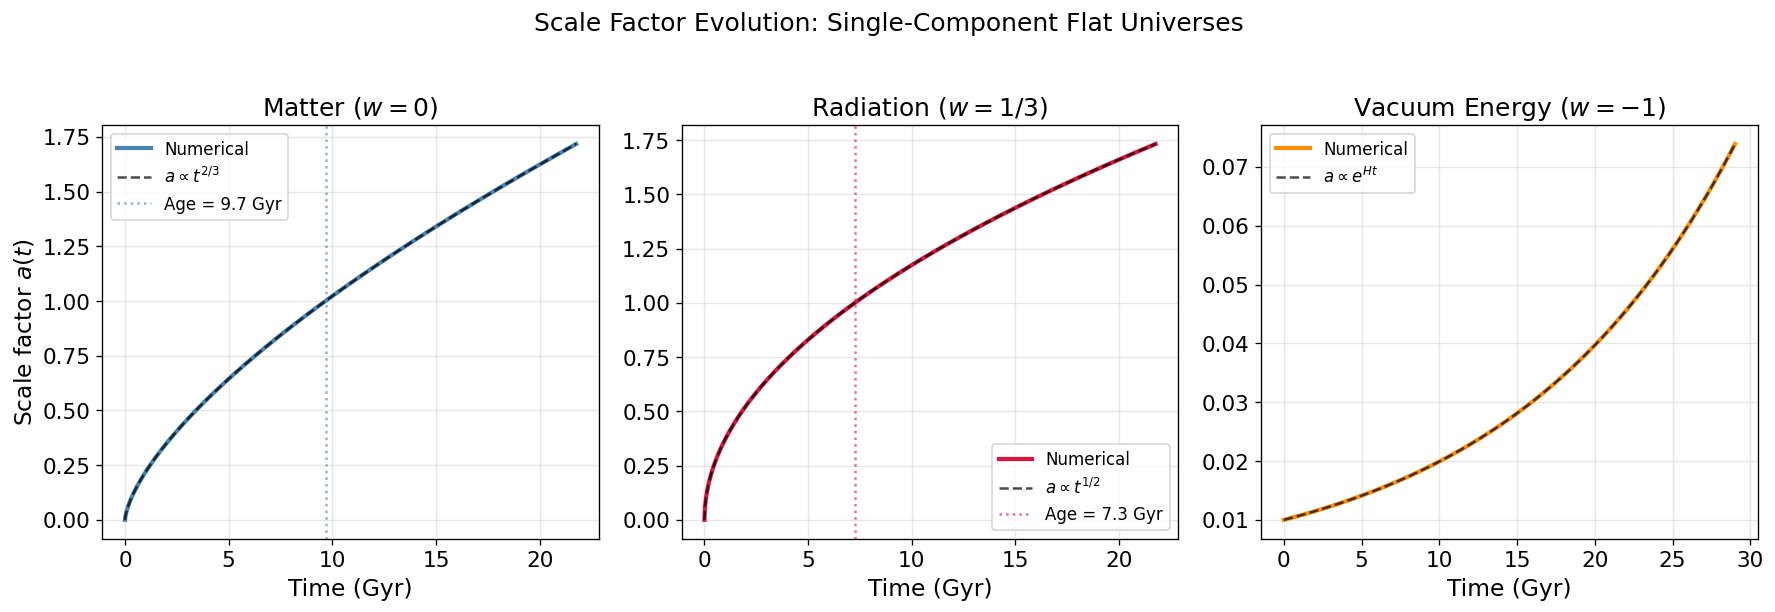

In [16]:
# ============================================================
# Comparison plot: all three single-component solutions
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Matter (Einstein-de Sitter) ---
ax = axes[0]
mask_m = (a_matter_num <= 2.5) & (t_Gyr_m > 0)
ax.plot(t_Gyr_m[mask_m], a_matter_num[mask_m], 'steelblue', lw=2.5, label='Numerical')
ax.plot(t_Gyr_m[mask_m], a_matter_ana[mask_m], 'k--', lw=1.5, alpha=0.7, label=r'$a \propto t^{2/3}$')
ax.axvline(t_age_EdS, color='steelblue', ls=':', alpha=0.6, label=f'Age = {t_age_EdS:.1f} Gyr')
ax.set_xlabel('Time (Gyr)')
ax.set_ylabel('Scale factor $a(t)$')
ax.set_title('Matter ($w=0$)')
ax.legend(fontsize=10)

# --- Radiation ---
ax = axes[1]
mask_r = (a_rad_num <= 2.5) & (t_Gyr_r > 0)
ax.plot(t_Gyr_r[mask_r], a_rad_num[mask_r], 'crimson', lw=2.5, label='Numerical')
ax.plot(t_Gyr_r[mask_r], a_rad_ana[mask_r], 'k--', lw=1.5, alpha=0.7, label=r'$a \propto t^{1/2}$')
ax.axvline(t_age_rad, color='crimson', ls=':', alpha=0.6, label=f'Age = {t_age_rad:.1f} Gyr')
ax.set_xlabel('Time (Gyr)')
ax.set_title('Radiation ($w=1/3$)')
ax.legend(fontsize=10)

# --- Lambda (de Sitter) ---
ax = axes[2]
mask_dS = a_dS_num <= 5.0
ax.plot(t_Gyr_dS[mask_dS], a_dS_num[mask_dS], 'darkorange', lw=2.5, label='Numerical')
ax.plot(t_Gyr_dS[mask_dS], a_dS_ana[mask_dS], 'k--', lw=1.5, alpha=0.7, label=r'$a \propto e^{Ht}$')
ax.set_xlabel('Time (Gyr)')
ax.set_title(r'Vacuum Energy ($w=-1$)')
ax.legend(fontsize=10)

plt.suptitle('Scale Factor Evolution: Single-Component Flat Universes', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('friedmann_single_component.png', bbox_inches='tight', dpi=150)
plt.show()

### Energy Density Evolution

The different scaling laws $\rho \propto a^{-3(1+w)}$ mean that different components dominate at different epochs:

- **Radiation** ($\rho_r \propto a^{-4}$) dominates at early times (small $a$) — the extra factor of $a^{-1}$ comes from photon redshift
- **Matter** ($\rho_m \propto a^{-3}$) dominates at intermediate times — simple dilution
- **Dark energy** ($\rho_\Lambda = $ const) dominates at late times — it does not dilute!

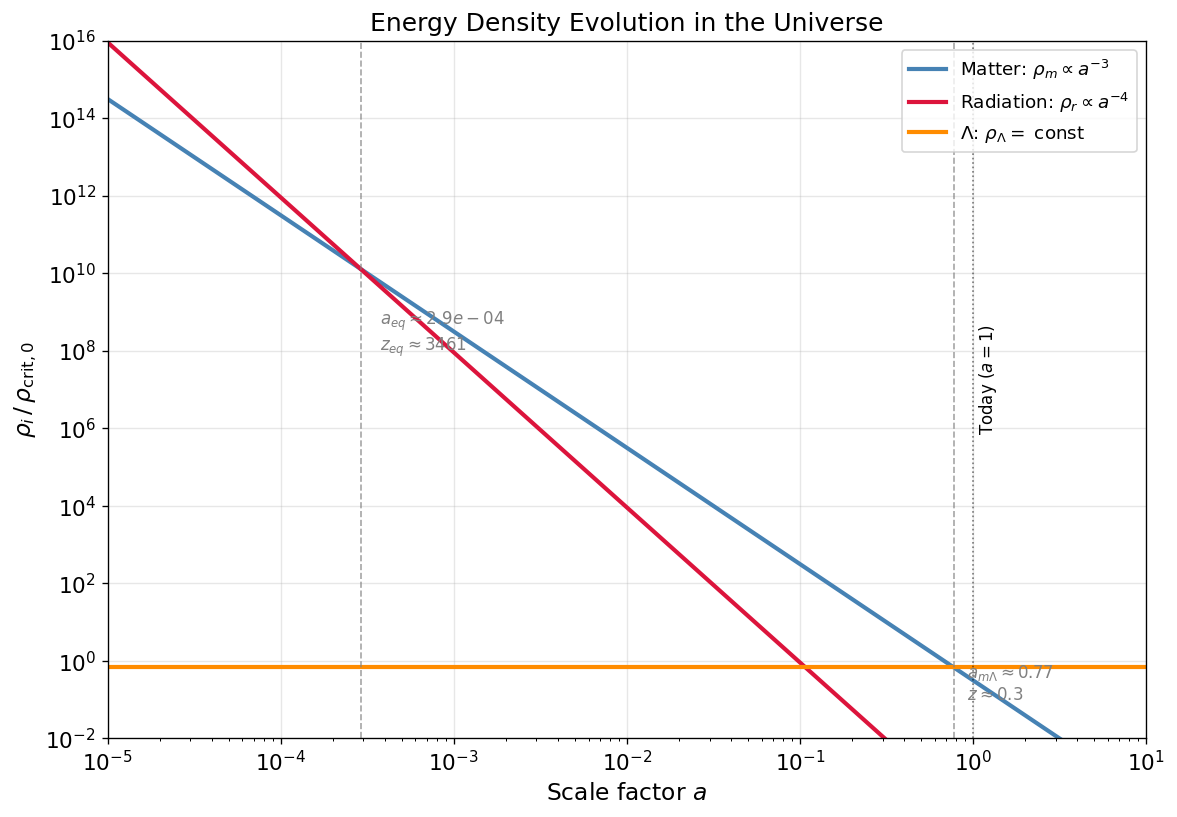

In [17]:
# ============================================================
# Density evolution: rho_i / rho_crit,0 vs scale factor
# ============================================================
a_range = np.logspace(-5, 1, 500)

# Planck 2018 density parameters
Omega_m0 = 0.315
Omega_r0 = 9.1e-5    # photons + neutrinos
Omega_L0 = 0.685

rho_matter = Omega_m0 * a_range**(-3)
rho_radiation = Omega_r0 * a_range**(-4)
rho_lambda = Omega_L0 * np.ones_like(a_range)

fig, ax = plt.subplots(figsize=(10, 7))
ax.loglog(a_range, rho_matter, 'steelblue', lw=2.5, label=r'Matter: $\rho_m \propto a^{-3}$')
ax.loglog(a_range, rho_radiation, 'crimson', lw=2.5, label=r'Radiation: $\rho_r \propto a^{-4}$')
ax.loglog(a_range, rho_lambda, 'darkorange', lw=2.5, label=r'$\Lambda$: $\rho_\Lambda = $ const')

# Matter-radiation equality
a_eq = Omega_r0 / Omega_m0
ax.axvline(a_eq, color='gray', ls='--', lw=1, alpha=0.7)
ax.text(a_eq * 1.3, 1e8, f'$a_{{eq}} \\approx {a_eq:.1e}$\n$z_{{eq}} \\approx {1/a_eq - 1:.0f}$',
        fontsize=10, color='gray')

# Matter-Lambda equality
a_mL = (Omega_m0 / Omega_L0)**(1.0 / 3.0)
ax.axvline(a_mL, color='gray', ls='--', lw=1, alpha=0.7)
ax.text(a_mL * 1.2, 1e-1, f'$a_{{m\\Lambda}} \\approx {a_mL:.2f}$\n$z \\approx {1/a_mL - 1:.1f}$',
        fontsize=10, color='gray')

ax.axvline(1.0, color='black', ls=':', lw=1, alpha=0.5)
ax.text(1.05, 1e6, 'Today ($a=1$)', fontsize=10, rotation=90)

ax.set_xlabel('Scale factor $a$')
ax.set_ylabel(r'$\rho_i \,/\, \rho_{\mathrm{crit},0}$')
ax.set_title('Energy Density Evolution in the Universe')
ax.legend(loc='upper right')
ax.set_xlim(1e-5, 10)
ax.set_ylim(1e-2, 1e16)

plt.tight_layout()
plt.savefig('density_evolution.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Part 4 — The $\Lambda$CDM Universe

A realistic universe contains matter, radiation, and dark energy simultaneously. The Friedmann equation becomes:

$$H^2(a) = H_0^2\left[\frac{\Omega_{r,0}}{a^4} + \frac{\Omega_{m,0}}{a^3} + \Omega_{\Lambda,0}\right]$$

We now solve this multi-component equation numerically to obtain:
- The expansion history $a(t)$
- The Hubble parameter $H(z)$
- The age of the Universe

We use the observed cosmological parameters from **Planck (2018)**:
- $\Omega_m = 0.315$, $\Omega_\Lambda = 0.685$, $\Omega_r \approx 9.1 \times 10^{-5}$
- $H_0 = 67.4$ km s$^{-1}$ Mpc$^{-1}$

In [18]:
# ============================================================
# Multi-component Friedmann ODE
# ============================================================
def friedmann_lcdm(t_sec, a_vec, H0, Om, Or, OL):
    """RHS of da/dt for a flat LCDM universe."""
    a_val = a_vec[0]
    if a_val <= 0:
        return [0.0]
    H_sq = H0**2 * (Or * a_val**(-4) + Om * a_val**(-3) + OL)
    return [a_val * np.sqrt(max(H_sq, 0.0))]

# Start deep in the radiation era, where radiation dominates.
# We need a_start much smaller than a_eq ~ 3e-4 so that we capture
# the full expansion history from the radiation era onward.
a_start = 1e-7   # scale factor at the start of integration

# In the radiation era, the Friedmann equation reduces to
# H ~ H0 * sqrt(Omega_r) / a^2, giving a ~ (2 H0 sqrt(Omega_r) t)^{1/2}.
# Inverting: t = a^2 / (2 H0 sqrt(Omega_r))
t_start_lcdm = a_start**2 / (2.0 * H0_si * np.sqrt(Omega_r0))   # seconds

# Integrate to 3 Hubble times (~43 Gyr) — well into the future
t_end_lcdm = 3.0 / H0_si   # seconds

sol_lcdm = solve_ivp(friedmann_lcdm, [t_start_lcdm, t_end_lcdm], [a_start],
                     args=(H0_si, Omega_m0, Omega_r0, Omega_L0),
                     dense_output=True, max_step=1e15,
                     rtol=1e-10, atol=1e-12)

# Find the age of the universe: the time at which a(t) = 1 (today)
def find_a1(t_val):
    return sol_lcdm.sol(t_val)[0] - 1.0

t_age_lcdm = brentq(find_a1, t_start_lcdm, t_end_lcdm)
age_Gyr = t_age_lcdm / Gyr_in_s

print(f"Age of the Universe (ΛCDM): {age_Gyr:.2f} Gyr")
print(f"Compare: Planck 2018 value: 13.80 ± 0.02 Gyr")

Age of the Universe (ΛCDM): 13.79 Gyr
Compare: Planck 2018 value: 13.80 ± 0.02 Gyr


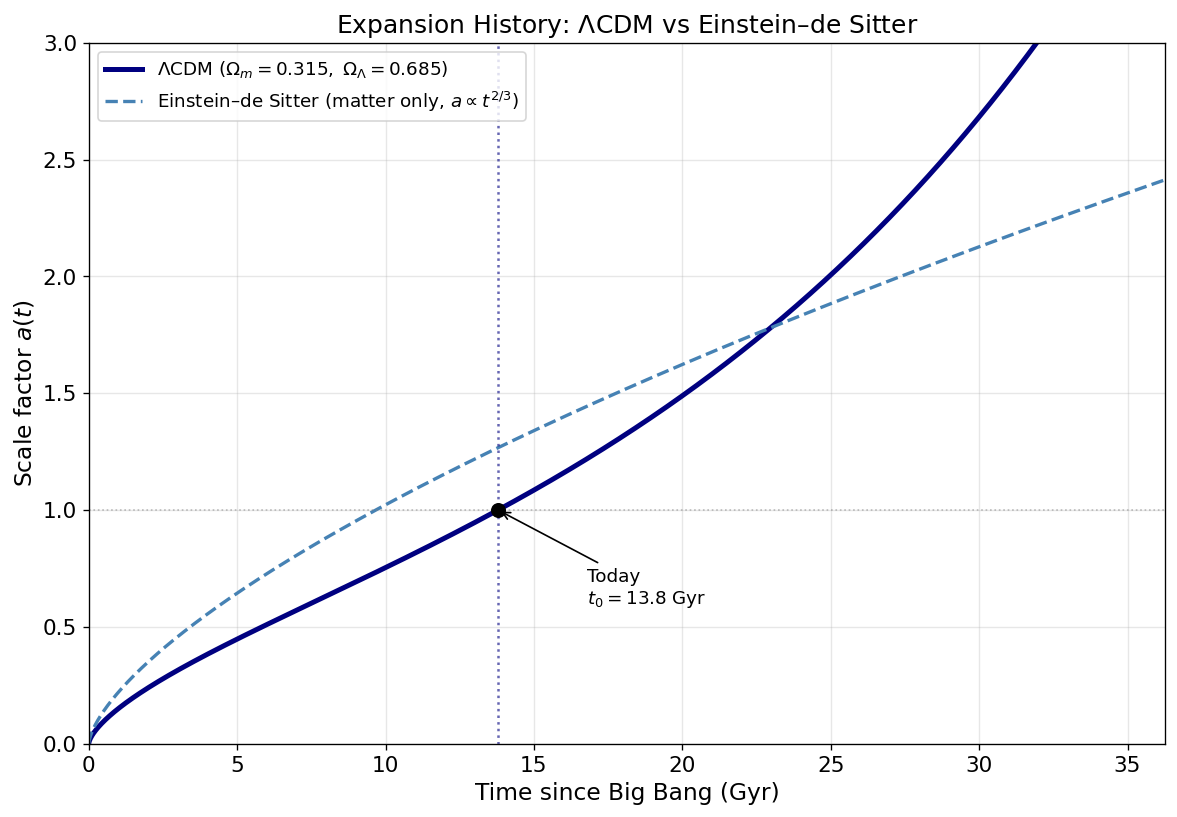

In [19]:
# ============================================================
# Plot LCDM scale factor vs Einstein-de Sitter
# ============================================================
t_plot = np.linspace(t_start_lcdm, 2.5 / H0_si, 2000)
a_lcdm_plot = sol_lcdm.sol(t_plot)[0]
t_plot_Gyr = t_plot / Gyr_in_s

# Matter-only for comparison
a_eds = (1.5 * H0_si * t_plot)**(2.0 / 3.0)

fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(t_plot_Gyr, a_lcdm_plot, 'navy', lw=3.0,
        label=r'$\Lambda$CDM ($\Omega_m=0.315,\;\Omega_\Lambda=0.685$)')
ax.plot(t_plot_Gyr, a_eds, 'steelblue', lw=2.0, ls='--',
        label=r'Einstein–de Sitter (matter only, $a \propto t^{2/3}$)')

# Mark today
ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.5)
ax.axvline(age_Gyr, color='navy', ls=':', lw=1.5, alpha=0.6)
ax.plot(age_Gyr, 1.0, 'ko', ms=8, zorder=10)
ax.annotate(f'Today\n$t_0 = {age_Gyr:.1f}$ Gyr',
            xy=(age_Gyr, 1.0), xytext=(age_Gyr + 3, 0.6),
            fontsize=11, arrowprops=dict(arrowstyle='->', color='k'))

ax.set_xlabel('Time since Big Bang (Gyr)')
ax.set_ylabel('Scale factor $a(t)$')
ax.set_title(r'Expansion History: $\Lambda$CDM vs Einstein–de Sitter')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(0, t_plot_Gyr[-1])
ax.set_ylim(0, 3.0)

plt.tight_layout()
plt.savefig('lcdm_scale_factor.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Part 5 — Student Exercise

### Exercise: Matter–Radiation Equality

The epoch of **matter–radiation equality** is a key milestone in the thermal history of the Universe.

**Tasks:**
1. Using $\Omega_m = 0.315$ and $\Omega_r = 9.1 \times 10^{-5}$, compute the redshift $z_{\rm eq}$ and scale factor $a_{\rm eq}$ at which $\rho_m = \rho_r$
2. Compute the temperature $T_{\rm eq}$ using $T_0 = 2.725$ K and $T = T_0 / a$
3. Plot $\rho_m(a)$ and $\rho_r(a)$ near the equality epoch and clearly mark the crossover
4. Compute the age of the Universe at matter–radiation equality using the Friedmann integral

**Hints:**
- At equality: $\Omega_m / a_{\rm eq}^3 = \Omega_r / a_{\rm eq}^4 \;\Longrightarrow\; a_{\rm eq} = \Omega_r / \Omega_m$
- Use `scipy.integrate.quad` for the age integral: $t_{\rm eq} = \frac{1}{H_0}\int_0^{z_{\rm eq}} \frac{dz}{(1+z)\,E(z)}$

In [23]:
# YOUR CODE HERE: Find the matter-radiation equality epoch
# Hint: at equality, Omega_m / a_eq^3 = Omega_r / a_eq^4
# so a_eq = Omega_r / Omega_m
# Use scipy.integrate.quad for the age integral


---
## Summary

In this tutorial you have:

1. **Defined the FLRW metric** symbolically using EinsteinPy and computed all non-zero Christoffel symbols, verifying them against the lecture notes
2. **Derived the Friedmann equations from first principles** by computing the Ricci tensor, Ricci scalar, and Einstein tensor from the FLRW metric
3. **Solved the Friedmann equations** numerically for single-component universes (matter, radiation, $\Lambda$) and confirmed agreement with the known analytical solutions: $a \propto t^{2/3}$, $a \propto t^{1/2}$, and $a \propto e^{Ht}$
4. **Integrated the full $\Lambda$CDM model** to obtain the expansion history, computed the age of the Universe ($t_0 \approx 13.8$ Gyr), and plotted the evolution of the energy densities.

### Key takeaways
- The Friedmann equations follow directly and uniquely from applying the cosmological principle (homogeneity + isotropy) to Einstein's field equations
- The equation of state parameter $w$ determines how each component dilutes and how the Universe expands
- The $\Lambda$CDM model, with its three components, provides a complete description of the expansion from the radiation era to the present accelerating phase
